In [20]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.0.5


In [21]:
#importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,classification_report
# pip install xgboost

In [22]:
#importing the dataset
df_churn=pd.read_csv(r"D:\My Program\Data Science Project\customer-churn\Churn_Data.csv")
df_churn.info()
df_churn.isnull().sum()
df_churn.head()
df_churn.drop(['Surname'],axis=1,inplace=True)
df_churn.drop(['Gender'],axis=1,inplace=True)
df_churn.drop(['RowNumber'],axis=1,inplace=True)
df_churn.drop(['CustomerId'],axis=1,inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [24]:
# Palette mapping
palette = {"Germany": "#F0E100", "France": "#01295F", "Spain": "#F17105"}
palette_df = pd.DataFrame(palette.items(), columns=['Geography', 'Color'])

In [25]:
# Count customers per geography
customersa = df_churn['Geography'].value_counts().reset_index()
customersa.columns = ['Geography', 'Count']

In [26]:
# Merge with color palette
customers = pd.merge(customersa, palette_df, on='Geography', how='left')

In [27]:
# Plot donut chart
fig = go.Figure(data=[go.Pie(
    labels=customers['Geography'],
    values=customers['Count'],
    textinfo='label+percent',
    name='Customers Geographical Locations',
    marker_colors=customers['Color'],
    hole=0.5
)])

fig.show()

In [30]:
# Color palette for countries
palette = {"Germany": "#F0E100", "France": "#01295F", "Spain": "#F17105"}
palette_df = pd.DataFrame(palette.items(), columns=['Geography', 'Color'])


In [31]:

# Split dataset into churners and non-churners
churners = df_churn[df_churn['Exited'] == 1]
nonchurners = df_churn[df_churn['Exited'] == 0]

In [32]:
# ---- Churners Count ----
churners_counta = churners['Geography'].value_counts().reset_index()
churners_counta.columns = ['Geography', 'Count']   # ✅ Correct column names
churners_count = pd.merge(churners_counta, palette_df, on='Geography', how='left')


In [33]:
# ---- Non-Churners Count ----
nonchurners_counta = nonchurners['Geography'].value_counts().reset_index()
nonchurners_counta.columns = ['Geography', 'Count']   # ✅ Correct column names
nonchurners_count = pd.merge(nonchurners_counta, palette_df, on='Geography', how='left')


In [34]:
# ---- Plot Subplots ----
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "pie"}]],
    subplot_titles=("Churners by Location", "Non-churners by Location")
)


In [35]:
# Churners Pie Chart
fig.add_trace(
    go.Pie(
        labels=churners_count['Geography'],
        values=churners_count['Count'],
        textinfo='label+percent',
        name='Churners Geographical Locations',
        marker_colors=churners_count['Color'],
        hole=0.5
    ), 1, 1
)



In [36]:
# Non-Churners Pie Chart
fig.add_trace(
    go.Pie(
        labels=nonchurners_count['Geography'],
        values=nonchurners_count['Count'],
        textinfo='label+percent',
        name='Non-Churners Geographical Locations',
        marker_colors=nonchurners_count['Color'],
        hole=0.5
    ), 1, 2
)

In [37]:
# Show the figure
fig.update_layout(title_text="Churners vs Non-Churners by Geography", showlegend=True)
fig.show()


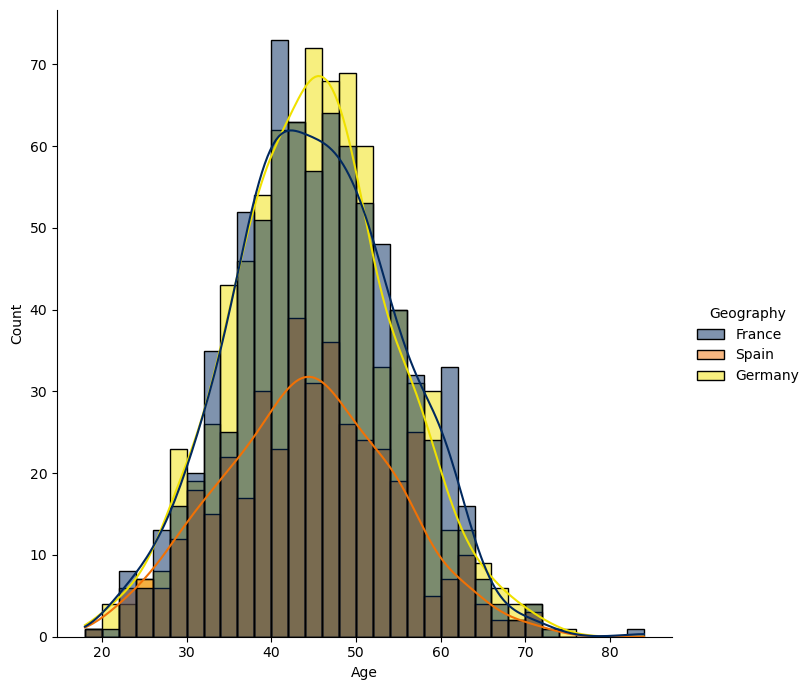

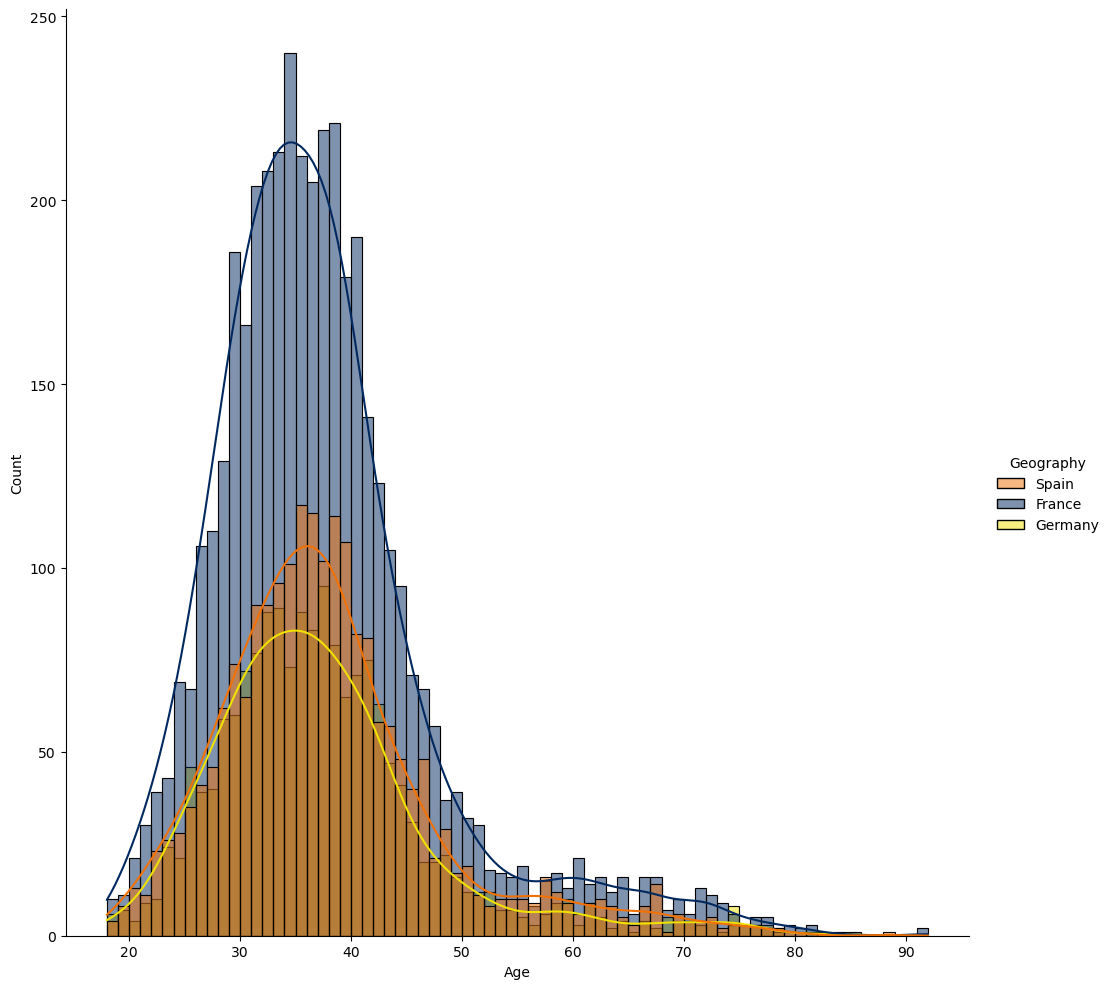

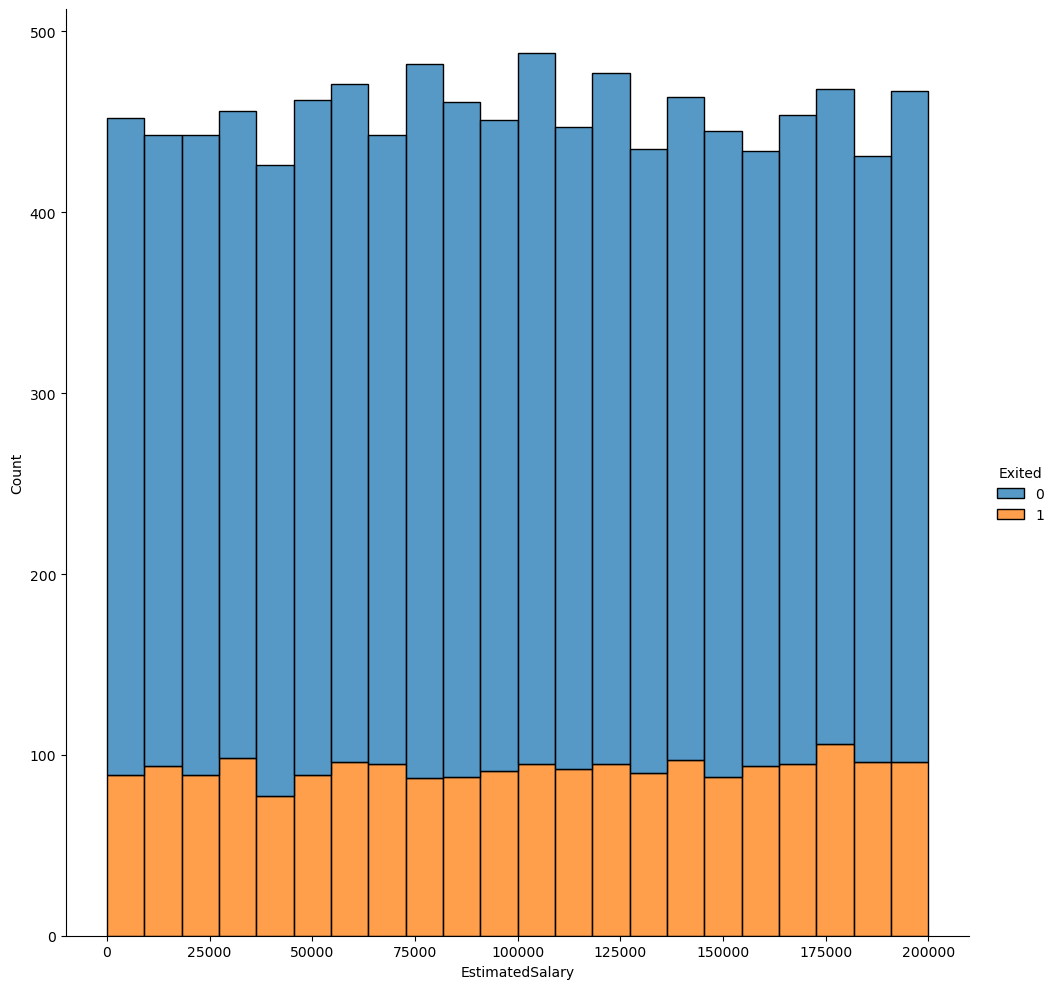

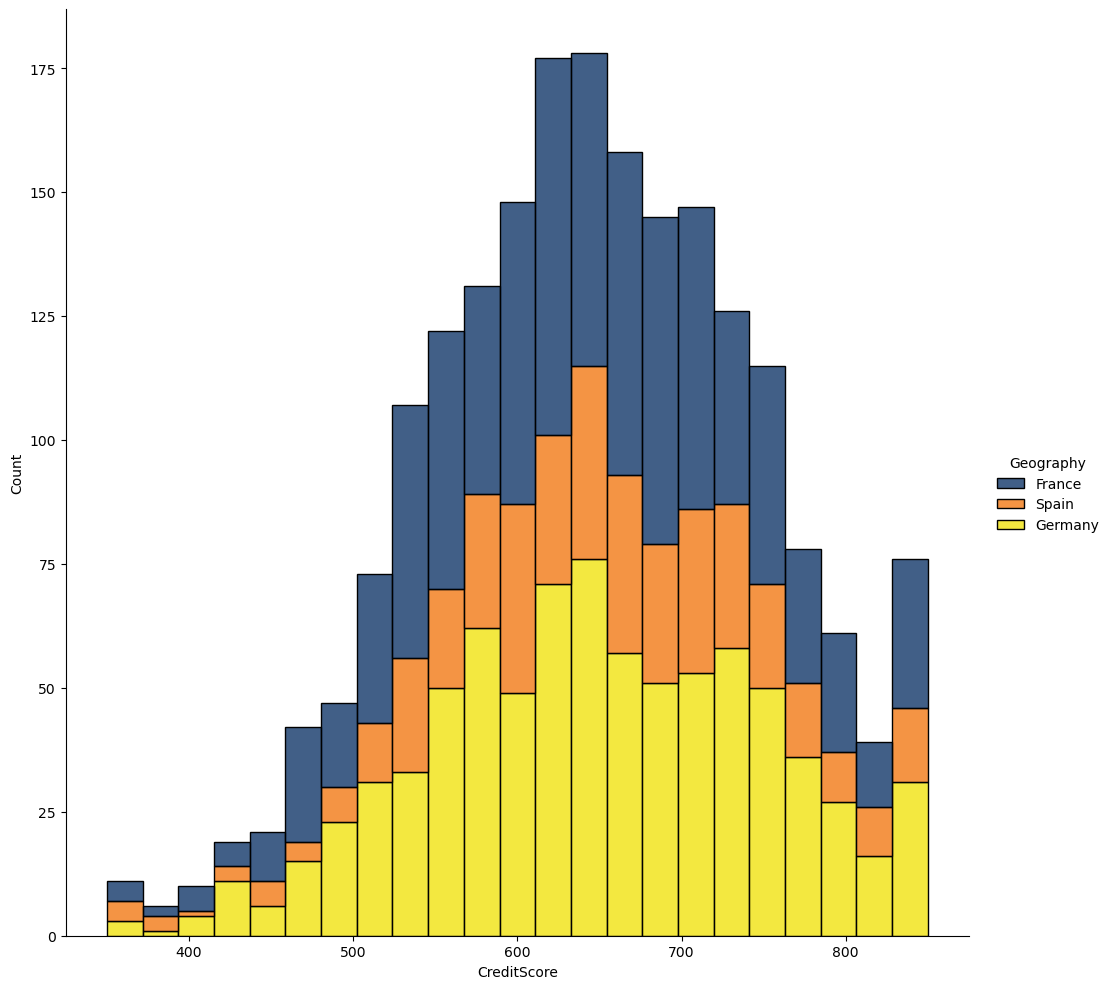

In [38]:
sns.displot(data=churners, x="Age", hue='Geography',kde=True,height=7,palette=palette)
sns.displot(data=nonchurners, x="Age", hue='Geography',kde=True,height=10,palette=palette)
sns.displot(df_churn, x="EstimatedSalary", hue="Exited",multiple="stack",height=10)
sns.displot(churners, x="CreditScore", hue="Geography", multiple="stack",height=10,palette=palette)
balance_df=pd.DataFrame(df_churn['Exited'].value_counts(normalize=False))
balance_df=balance_df.reset_index().rename(columns = {'index':'Exited','Exited':'Count'})
balance_df
df_churn['Geography'].unique()
le = LabelEncoder()
df_churn['Geography']=le.fit_transform(df_churn['Geography'])

In [39]:
#The dictionary of this encoding is:
le_geography_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
le_geography_mapping

{'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}

In [40]:
X = df_churn.drop("Exited", axis=1)
y = df_churn['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [41]:
#XGBoost
xgb_churn = xgb.XGBClassifier(gamma= 1.0,learning_rate= 0.15,max_depth= 7,
                              n_estimators= 100)
xgb_churn.fit(X_train, y_train)
predictions = xgb_churn.predict(X_test)
accuracy_xgb = accuracy_score(y_test, predictions) * 100
print("The accuracy score of the XGBoost Classification Model is: ",accuracy_xgb)

The accuracy score of the XGBoost Classification Model is:  87.16000000000001


In [43]:
# Scale data
sc = StandardScaler()
X_rftrain = sc.fit_transform(X_train)
X_rftest = sc.transform(X_test)

In [44]:
# Random Forest model (fixed max_features)
rfc = RandomForestClassifier(
    criterion='gini',
    n_estimators=100,
    random_state=10,
    max_features='sqrt'  # or simply remove this parameter
)


In [45]:
# Train model
rfc.fit(X_rftrain, y_train)

RandomForestClassifier(random_state=10)

In [46]:
# Evaluating on Training set
rfc_pred_train = rfc.predict(X_rftrain)

In [47]:
# Evaluating on Test set
rfc_pred_test = rfc.predict(X_rftest)
confusion_matrix(y_test, rfc_pred_test)

array([[1911,   69],
       [ 276,  244]])

In [48]:
# Display accuracy score
accuracy_rf=accuracy_score(y_test, rfc_pred_test)*100
print("The accuracy score of the Random Forest Classification Model is: ",accuracy_rf)
print(classification_report(y_test, rfc_pred_test))

The accuracy score of the Random Forest Classification Model is:  86.2
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1980
           1       0.78      0.47      0.59       520

    accuracy                           0.86      2500
   macro avg       0.83      0.72      0.75      2500
weighted avg       0.85      0.86      0.85      2500



In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


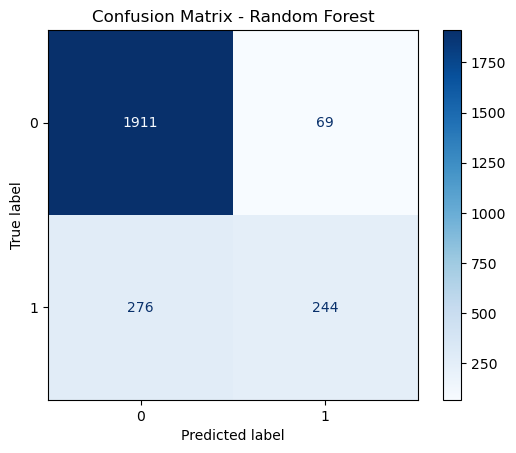

In [51]:
# Confusion Matrix

cm = confusion_matrix(y_test, rfc_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [52]:
# ROC Curve & AUC Score
# Get prediction probabilities
y_prob = rfc.predict_proba(X_rftest)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

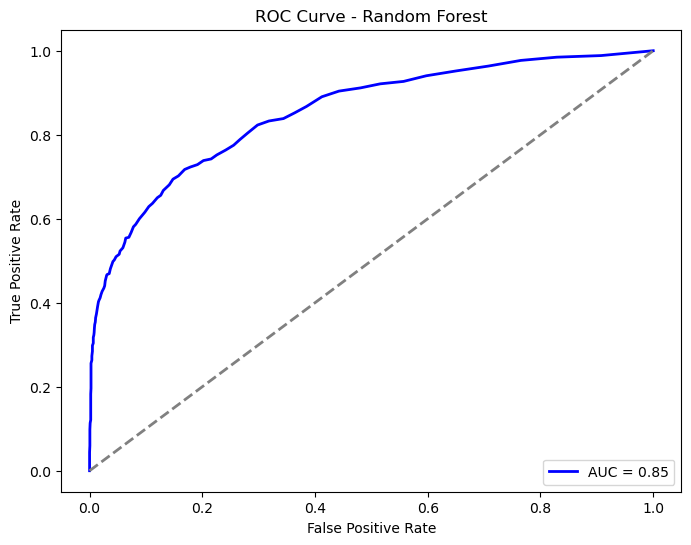

In [53]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()


In [54]:
# Feature Importance Plot
feature_importances = rfc.feature_importances_
indices = np.argsort(feature_importances)[::-1]
features = X_train.columns if hasattr(X_train, "columns") else np.arange(len(feature_importances))


C:\Users\91961\AppData\Local\Temp\ipykernel_26504\1713594944.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




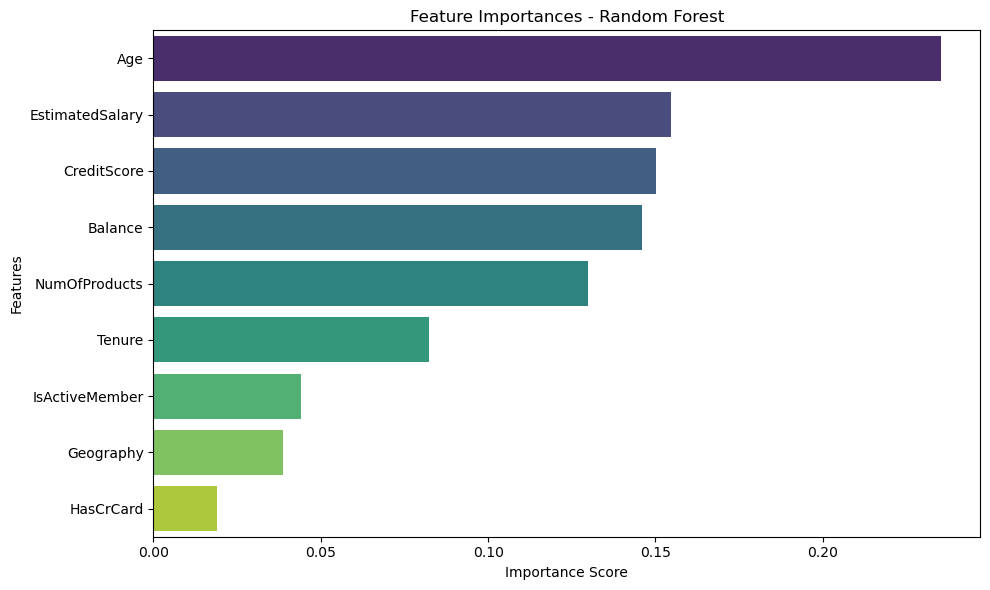

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [56]:
# Final Evaluation

print("\nFinal Evaluation Metrics:")
print("Accuracy      :", accuracy_rf)
print("AUC Score    :", roc_auc)
print("Confusion Matrix:\n", cm)


Final Evaluation Metrics:
Accuracy      : 86.2
AUC Score    : 0.8534872766122765
Confusion Matrix:
 [[1911   69]
 [ 276  244]]


In [57]:
# 📌 Import necessary libraries
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

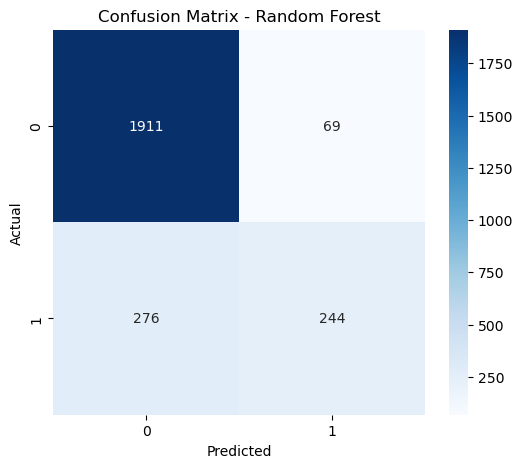

In [59]:
# ✅ 1. Confusion Matrix

cm = confusion_matrix(y_test, rfc_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rfc.classes_, yticklabels=rfc.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [60]:
# ✅ 2. ROC Curve & AUC Score

# Get predicted probabilities
y_prob = rfc.predict_proba(X_rftest)[:, 1]

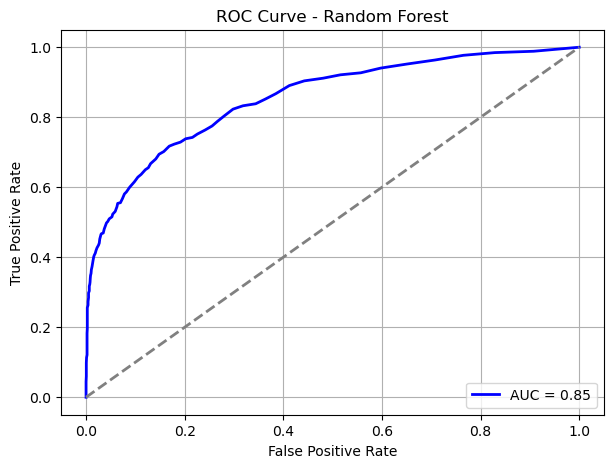

In [61]:
# Calculate FPR, TPR, and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=2)
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [62]:
# Get feature importances
feature_importances = rfc.feature_importances_
indices = np.argsort(feature_importances)[::-1]

C:\Users\91961\AppData\Local\Temp\ipykernel_26504\2064696892.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




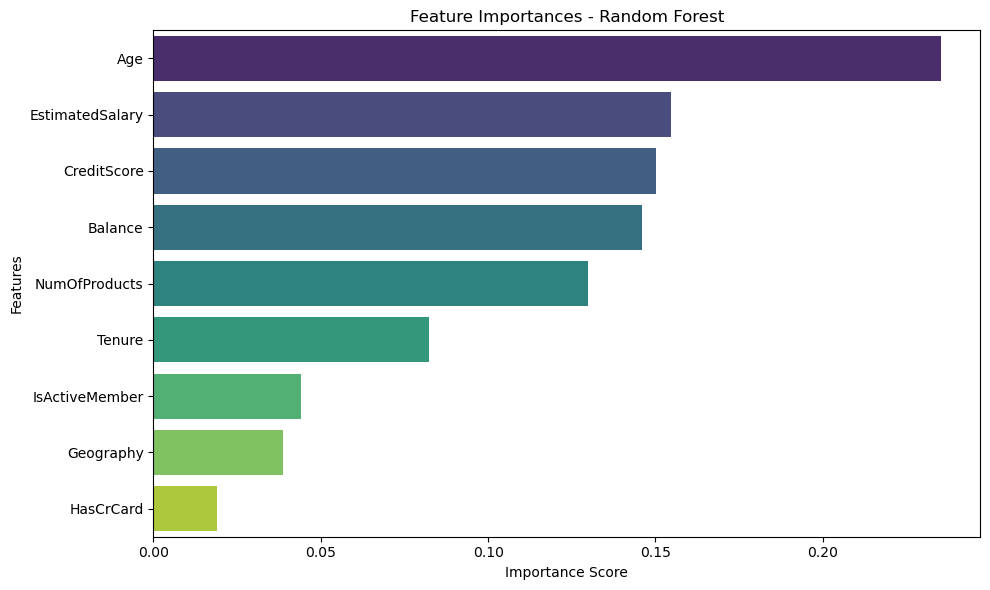

In [63]:
# If using a DataFrame, fetch column names
if hasattr(X_train, "columns"):
    features = X_train.columns
else:
    features = [f"Feature {i}" for i in range(X_train.shape[1])]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[indices], y=np.array(features)[indices], palette="viridis")
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [64]:
# ✅ 4. Final Evaluation Metrics

print("🔹 Final Evaluation Metrics")
print("-------------------------------------------------")
print(f"✅ Accuracy Score   : {accuracy_rf:.2f}%")
print(f"✅ AUC Score        : {roc_auc:.2f}")
print("✅ Classification Report:\n")
print(classification_report(y_test, rfc_pred_test))
print("✅ Confusion Matrix:\n", cm)

🔹 Final Evaluation Metrics
-------------------------------------------------
✅ Accuracy Score   : 86.20%
✅ AUC Score        : 0.85
✅ Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1980
           1       0.78      0.47      0.59       520

    accuracy                           0.86      2500
   macro avg       0.83      0.72      0.75      2500
weighted avg       0.85      0.86      0.85      2500

✅ Confusion Matrix:
 [[1911   69]
 [ 276  244]]
